# Data 

### Data intake, formatting, and cleaning 

warning: this takes so long to run in full

```
"if i could open my arms
and span the length of the isle of manhattan
id bring it to where you are
making a lake of the east river and hudson" - death cab for cutie
```


In [67]:
source("src/functions_and_things.r")

load_libraries()

## Pre polic data

https://data.ny.gov/Transportation/MTA-Subway-Hourly-Ridership-2020-2024/wujg-7c2s/about_data

June 1, 2024-December 31, 2024

* `subway_pre_df_jun` - June 1, 2024 - July 31, 2024
* `subway_pre_df_aug` - August 1, 2024 - September 31, 2024
* `subway_pre_df_oct` - October 1, 2024 - December 31, 2024

In [74]:
subway_pre_df_jun = read.csv("/Users/Local/statsproject/data/ignore/MTA_Jun2024_Subway_Hourly.csv")

subway_pre_df_aug = read.csv("/Users/Local/statsproject/data/ignore/MTA_Aug2024_Subway_Hourly.csv")

subway_pre_df_oct = read.csv("/Users/Local/statsproject/data/ignore/MTA_Oct2024_Subway_Hourly.csv")

In [81]:
subway_pre_df = rbind(subway_pre_df_oct, 
                      subway_pre_df_aug, 
                      subway_pre_df_jun)

subway_pre_df$time = 0

subway_pre_df |> 
    select(transit_timestamp, borough, fare_class_category, ridership, latitude, longitude, time) -> subway_pre_df

nrow(subway_pre_df) == (nrow(subway_pre_df_aug) + nrow(subway_pre_df_jun) + nrow(subway_pre_df_oct))

[1] TRUE

## Post policy data

January 1, 2025 - December 31, 2025

* `subway_post_df_jan` - January 01, 2025 - July 01, 2025
* `subway_post_df_jul` - July 01, 2025 - Decemeber 31, 2025

In [ ]:
subway_post_df_jan = read.csv("data/ignore/MTA_Jan2025_Subway_Hourly.csv")

subway_post_df_jul = read.csv("data/ignore/MTA_Jul2025_Subway_Hourly.csv")

subway_post_df_jan |> select(-transit_mode) -> subway_post_df_jan

In [112]:
subway_post_df_jul |> select(transit_timestamp,	borough, fare_class_category, ridership, latitude, longitude) -> subway_post_df_jul

In [113]:
head(subway_post_df_jan)
head(subway_post_df_jul)

,transit_timestamp,borough,fare_class_category,ridership,latitude,longitude
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,01/01/2025 12:00:00 AM,Brooklyn,Metrocard - Full Fare,8,40.71457,-73.94405
2,01/01/2025 12:00:00 AM,Brooklyn,Metrocard - Full Fare,59,40.69934,-73.99053
3,01/01/2025 12:00:00 AM,Brooklyn,OMNY - Other,5,40.68712,-73.97537
4,01/01/2025 12:00:00 AM,Bronx,Metrocard - Fair Fare,2,40.81047,-73.92614
5,01/01/2025 12:00:00 AM,Bronx,Metrocard - Other,1,40.81323,-73.92985
6,01/01/2025 12:00:00 AM,Queens,Metrocard - Other,2,40.70618,-73.89587


,transit_timestamp,borough,fare_class_category,ridership,latitude,longitude
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,07/01/2025 12:00:00 AM,Brooklyn,Metrocard - Fair Fare,1,40.64665,-73.90185
2,07/01/2025 12:00:00 AM,Bronx,Metrocard - Unlimited 7-Day,2,40.87481,-73.87885
3,07/01/2025 12:00:00 AM,Brooklyn,OMNY - Full Fare,2,40.61514,-73.97420
4,07/01/2025 12:00:00 AM,Brooklyn,OMNY - Students,1,40.68963,-73.95352
5,07/01/2025 12:00:00 AM,Manhattan,Metrocard - Seniors & Disability,1,40.77344,-73.98221
6,07/01/2025 12:00:00 AM,Manhattan,Metrocard - Unlimited 30-Day,4,40.77344,-73.98221


In [114]:
subway_post_df = rbind(subway_post_df_jan, 
                      subway_post_df_jul)

subway_post_df$time = 1

nrow(subway_post_df) == (nrow(subway_post_df_jan) + nrow(subway_post_df_jul))

[1] TRUE

In [115]:
nrow(subway_post_df)
nrow(subway_pre_df)

[1] 24436592

[1] 14853834

## Stacking pre and post datasets 

June 2024 - June 2025

24 million rows

In [116]:
head(subway_pre_df)

head(subway_post_df)

,transit_timestamp,borough,fare_class_category,ridership,latitude,longitude,time
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,10/05/2024 09:00:00 PM,Queens,OMNY - Full Fare,86,40.77504,-73.91203,0
2,12/07/2024 07:00:00 PM,Queens,Metrocard - Full Fare,30,40.77504,-73.91203,0
3,10/27/2024 04:00:00 PM,Queens,Metrocard - Full Fare,32,40.77504,-73.91203,0
4,11/17/2024 11:00:00 PM,Queens,Metrocard - Other,2,40.77504,-73.91203,0
5,11/03/2024 07:00:00 PM,Queens,OMNY - Students,8,40.77504,-73.91203,0
6,10/12/2024 03:00:00 PM,Queens,Metrocard - Unlimited 7-Day,32,40.77504,-73.91203,0


,transit_timestamp,borough,fare_class_category,ridership,latitude,longitude,time
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,01/01/2025 12:00:00 AM,Brooklyn,Metrocard - Full Fare,8,40.71457,-73.94405,1
2,01/01/2025 12:00:00 AM,Brooklyn,Metrocard - Full Fare,59,40.69934,-73.99053,1
3,01/01/2025 12:00:00 AM,Brooklyn,OMNY - Other,5,40.68712,-73.97537,1
4,01/01/2025 12:00:00 AM,Bronx,Metrocard - Fair Fare,2,40.81047,-73.92614,1
5,01/01/2025 12:00:00 AM,Bronx,Metrocard - Other,1,40.81323,-73.92985,1
6,01/01/2025 12:00:00 AM,Queens,Metrocard - Other,2,40.70618,-73.89587,1


In [117]:
df <- rbind(subway_pre_df, subway_post_df)

before_nrow <- nrow(df)

In [118]:
nrow(df) == nrow(subway_post_df) + nrow(subway_pre_df)

[1] TRUE

In [119]:
df = distinct(df)  # remove duplicates in case i messed dates up

In [121]:
after_nrow <- nrow(df)

paste0("Before, in the combined set, there were ", before_nrow, " rows. After removing duplicates there were ", after_nrow )
paste(before_nrow - after_nrow, "rows were removed")

[1] "Before, in the combined set, there were 39290426 rows. After removing duplicates there were 39228832"

[1] "61594 rows were removed"

segment, failsafe

In [122]:
write.csv(df, "data/ignore/raw_hourly.csv")

reload here to avoid running all, will still take foreveer (50 seconds to reload data)

In [123]:
library(lubridate)

In [124]:
df <- read.csv("data/ignore/raw_hourly.csv")

In [125]:
# ref 1 , ref 2
df |> mutate(
        transit_timestamp = trimws(transit_timestamp),
        datetime = mdy_hms(transit_timestamp),
        date = as.Date(datetime),
        time = format(datetime, "%H:%M:%S")) -> df

Focus on morning rush hour, weekdays

In [126]:
head(df)

,X,transit_timestamp,borough,fare_class_category,ridership,latitude,longitude,time,datetime,date
,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dttm>,<date>
1,1,10/05/2024 09:00:00 PM,Queens,OMNY - Full Fare,86,40.77504,-73.91203,21:00:00,2024-10-05 21:00:00,2024-10-05
2,2,12/07/2024 07:00:00 PM,Queens,Metrocard - Full Fare,30,40.77504,-73.91203,19:00:00,2024-12-07 19:00:00,2024-12-07
3,3,10/27/2024 04:00:00 PM,Queens,Metrocard - Full Fare,32,40.77504,-73.91203,16:00:00,2024-10-27 16:00:00,2024-10-27
4,4,11/17/2024 11:00:00 PM,Queens,Metrocard - Other,2,40.77504,-73.91203,23:00:00,2024-11-17 23:00:00,2024-11-17
5,5,11/03/2024 07:00:00 PM,Queens,OMNY - Students,8,40.77504,-73.91203,19:00:00,2024-11-03 19:00:00,2024-11-03
6,6,10/12/2024 03:00:00 PM,Queens,Metrocard - Unlimited 7-Day,32,40.77504,-73.91203,15:00:00,2024-10-12 15:00:00,2024-10-12


In [127]:
# time im calling rush hour referenced from the MA south shore breakdown lane travel signs
df |> 
    filter(time >= "07:0:00" & time <= "11:00:00") |>
    select(ridership, date, fare_class_category, borough) |>
    mutate(ridership = as.integer(ridership),
           day = weekdays(as.Date(date))
           ) -> df_rush

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `ridership = as.integer(ridership)`.
Caused by warning:
! NAs introduced by coercion”


In [128]:
head(df_rush)

,ridership,date,fare_class_category,borough,day
,<int>,<date>,<chr>,<chr>,<chr>
1,6,2024-10-18,OMNY - Other,Queens,Friday
2,30,2024-12-12,Metrocard - Unlimited 7-Day,Queens,Thursday
3,848,2024-11-04,OMNY - Full Fare,Queens,Monday
4,55,2024-11-22,Metrocard - Other,Queens,Friday
5,27,2024-10-06,Metrocard - Unlimited 7-Day,Queens,Sunday
6,2,2024-11-06,OMNY - Other,Queens,Wednesday


In [129]:
df_rush |> filter(!day %in% c("Saturday", "Sunday")) -> df_rush

In [130]:
colSums(is.na(df_rush))

ridership                date fare_class_category             borough 
              37709                   0                   0                   0 
                day 
                  0

Don't really know why theres so many missing ridership values. Mildly concerning but I'm going to drop them. 

In [131]:
df_rush |> filter(!is.na(ridership)) -> df_rush

nrow(df_rush)

[1] 6889426

In [132]:
head(df_rush)

,ridership,date,fare_class_category,borough,day
,<int>,<date>,<chr>,<chr>,<chr>
1,6,2024-10-18,OMNY - Other,Queens,Friday
2,30,2024-12-12,Metrocard - Unlimited 7-Day,Queens,Thursday
3,848,2024-11-04,OMNY - Full Fare,Queens,Monday
4,55,2024-11-22,Metrocard - Other,Queens,Friday
5,2,2024-11-06,OMNY - Other,Queens,Wednesday
6,235,2024-12-16,OMNY - Students,Queens,Monday


## CBD Boolean

By latitude/ longitude

 (scrapped)

<img src="/Users/Local/statsproject/pics/cbd_subway_coordbox.jpg" width="400" height="400">

In [133]:
# lat_high = 40.771372
# long_high= -74.00782 

# lat_low = 40.696999
# long_low = -73.966776 

In [134]:
# df$coords_cbd <- with(df, 
#    latitude >= lat_low & latitude <= lat_high & 
#    longitude <= long_low & longitude >= long_high)

Was the subway encoding close to the box one? 

In [135]:
# sum(df$coords_cbd == TRUE)

In [136]:
# sum(is.na(df$ridership))

# df <- drop_na(df, ridership)

## Aggregate dataset

In [137]:
df_rush |> 
    group_by(date, borough) |> 
    summarise(
        ridership = sum(ridership, na.rm = TRUE),
        .groups = "drop") |>
    select(date, borough, ridership) -> df_daily

In [138]:
head(df_daily, 10)

date,borough,ridership
<date>,<chr>,<int>
2024-06-03,Bronx,81362
2024-06-03,Brooklyn,262036
2024-06-03,Manhattan,316780
2024-06-03,Queens,174702
2024-06-04,Bronx,84976
2024-06-04,Brooklyn,284948
2024-06-04,Manhattan,335157
2024-06-04,Queens,181062
2024-06-05,Bronx,86655


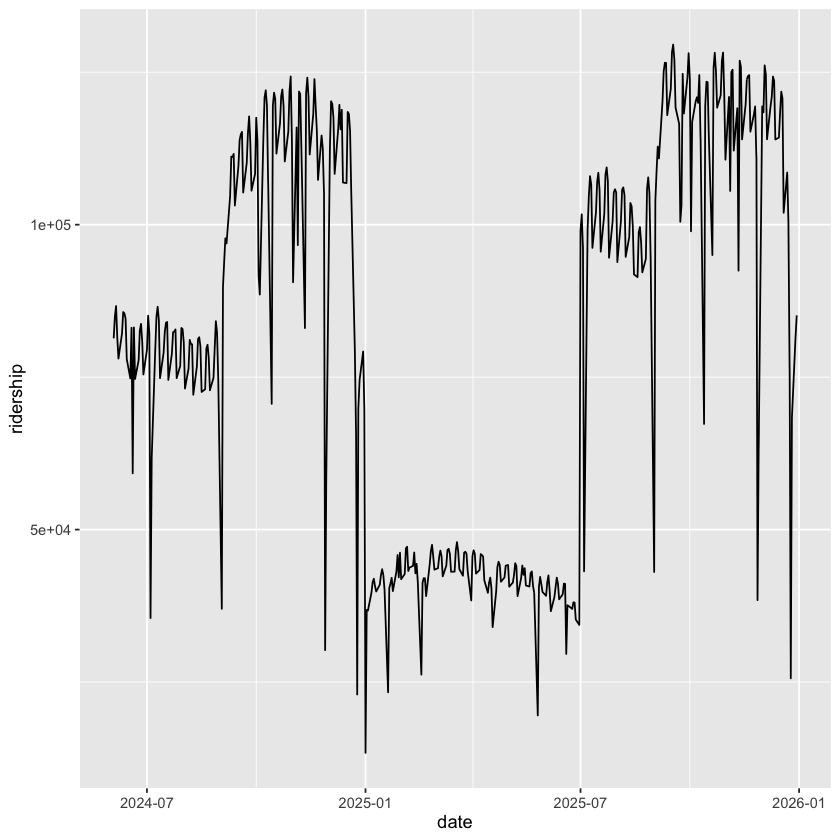

In [139]:
df_daily |> filter(borough == "Bronx") |> 
    ggplot(aes(x = date, y = ridership)) + geom_line()

## Checks

In [140]:
nrow(df_daily)

[1] 1648

In [141]:
n_distinct(df_daily$date)

[1] 412

In [142]:
write.csv(df_daily, "data/daily_ridership.csv", row.names = FALSE)

## Weather Data

Weather data from JFK International Airport reported on NOAA

Unit: Daily

https://www.ncdc.noaa.gov/cdo-web/ 

In [143]:
weather_df <- read.csv("data/weather.csv")

weather_df |> 
    rename(
        min_temp = TMIN, 
        snow = SNWD,
        rain = PRCP) |> 
    mutate(date = as.Date(DATE), format = "%m-%d-%Y") |> 
    select(date, min_temp, snow, rain) -> weather_df

head(weather_df)

,date,min_temp,snow,rain
,<date>,<int>,<dbl>,<dbl>
1,2024-06-01,62,0,0.00
2,2024-06-02,62,0,0.00
3,2024-06-03,66,0,0.02
4,2024-06-04,64,0,0.00
5,2024-06-05,63,0,0.04
6,2024-06-06,69,0,0.58


## Economic Data

Unemployment rate data from NYC / Neward from FRED 

Unit: Monthly

https://fred.stlouisfed.org/series/NEWY636URN# 

In [144]:
econ_df <- read.csv("/Users/Local/statsproject/data/NEWY636URN.csv")

econ_df |> 
    mutate(month = as.Date(observation_date, format = "%Y-%m-%d"),
           unemp = NEWY636URN) |> 
    select(month, unemp) -> econ_df

head(econ_df)

,month,unemp
,<date>,<dbl>
1,2024-06-01,4.7
2,2024-07-01,5.2
3,2024-08-01,5.1
4,2024-09-01,4.3
5,2024-10-01,4.5
6,2024-11-01,4.5


In [146]:
sum(is.na(econ_df$unemp))

[1] 0

## Weekly aggregation

Mostly for noise reduction in the plots and stuff

In [ ]:
# ref 5

df_daily |> 
    mutate(week = floor_date(date, "week")) |>
    group_by(week, borough)  -> df_weekly

In [149]:
head(df_weekly)

date,borough,ridership,week
<date>,<chr>,<int>,<date>
2024-06-03,Bronx,81362,2024-06-02
2024-06-03,Brooklyn,262036,2024-06-02
2024-06-03,Manhattan,316780,2024-06-02
2024-06-03,Queens,174702,2024-06-02
2024-06-04,Bronx,84976,2024-06-02
2024-06-04,Brooklyn,284948,2024-06-02


In [150]:
write.csv(df_weekly, "data/combined_data_weekly.csv", row.names = FALSE)